In [1]:
import scanpy as sc
import anndata
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import torch
import pickle
from sklearn import preprocessing
import json

In [2]:
adata = sc.read("adata_U2OS_DeepCycle.h5ad")
adata.var.index = adata.var['name']
adata

AnnData object with n_obs × n_vars = 1040 × 13450
    obs: 'Well_Plate', 'plate', 'phase', 'MeanGreen530', 'MeanRed585', 'fucci_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'original_louvain_wp', 'original_louvain', 'Green530', 'Red585', 'louvain', 'theta', 'cell_cycle_theta'
    var: 'name', 'biotype', 'description', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'GeneName', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'louvain', 'neighbors', 'pca', 'phase_colors', 'plate_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'ambiguous', 'matrix', 'spanning', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

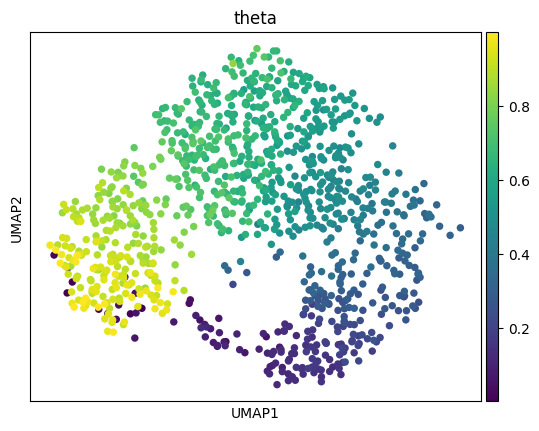

In [3]:
sc.pl.umap(adata,color='theta')

In [4]:
th=adata.obs['theta']
minima = min(th)
maxima = max(th)
norm = matplotlib.colors.Normalize(vmin=minima, vmax=maxima)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.coolwarm)

(array([ 39.,  78.,  82.,  76., 101., 143., 221.,  72., 119., 109.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

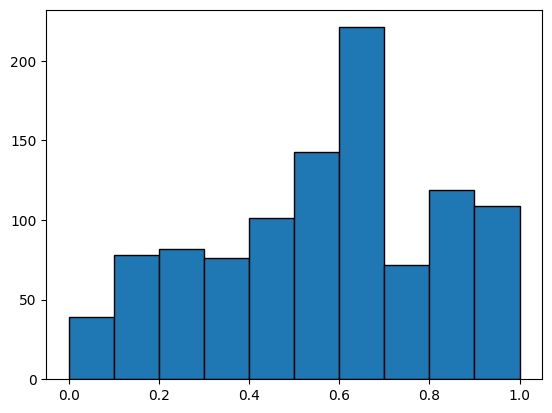

In [5]:
plt.hist(adata.obs['theta'], range=(0, 1), bins=10, edgecolor='black')
# plt.savefig('umap_cell_cycle_theta.png')

In [6]:
## 按相位角划分数据
n_bins = 50
bin_labels = np.arange(n_bins)
bin_edges = np.percentile(adata.obs['theta'], np.linspace(0, 100, n_bins+1))

In [7]:
adata.obs['bins'] = pd.cut(adata.obs['theta'], bins=bin_edges, labels=bin_labels, include_lowest=True)
adata.obs['bins'].value_counts()

bins
0     21
23    21
1     21
26    21
28    21
29    21
30    21
32    21
33    21
34    21
35    21
37    21
38    21
39    21
41    21
42    21
43    21
44    21
46    21
47    21
48    21
24    21
25    21
49    21
7     21
6     21
5     21
10    21
11    21
21    21
12    21
14    21
15    21
16    21
17    21
3     21
2     21
19    21
20    21
8     21
4     20
45    20
22    20
40    20
9     20
13    20
31    20
18    20
27    20
36    20
Name: count, dtype: int64

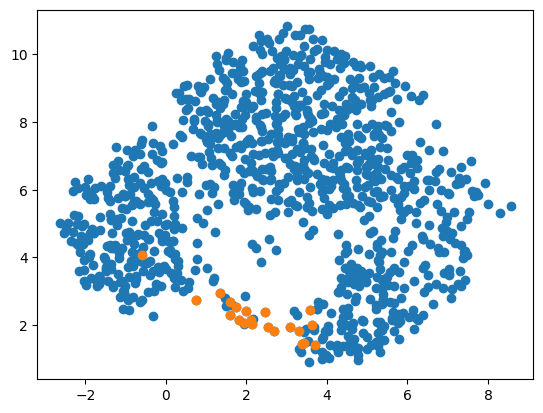

In [8]:
bdata = adata[adata.obs['bins'] == 1]
plt.scatter(adata.obsm['X_umap'][:,0],adata.obsm['X_umap'][:,1])
plt.scatter(bdata.obsm['X_umap'][:,0],bdata.obsm['X_umap'][:,1])

In [9]:
# list_of_genes_file = "genes_filter.json"
# expression_threshold = 5
# with open(list_of_genes_file,'r') as fp:
#     cell_cycle_genes = json.load(fp)

list_of_genes_file = "GO_cell_cycle_annotation_human.txt"
cell_cycle_genes = []
expression_threshold = 5
with open(list_of_genes_file,'r') as fp:
    for line in fp:
        line = line.rstrip()
        if line != '':
            cell_cycle_genes.append(line)

In [10]:
len(cell_cycle_genes)

1842

In [11]:
## 数据准备
def generate_input(list_of_genes, adata):
    gene_list = list(adata.var.index)
    n = gene_list.index(list_of_genes[0])
    df_all = pd.DataFrame({ 'spliced':adata.layers['Ms'][:,n], 'unspliced':adata.layers['Mu'][:,n] })

    for gene in list_of_genes[1:]:
        try:
            n = gene_list.index(gene)
            df = pd.DataFrame({ 'spliced':adata.layers['Ms'][:,n], 'unspliced':adata.layers['Mu'][:,n] })
            if (df.mean()<expression_threshold).all():
                list_of_genes.remove(gene)
                continue
        except ValueError:
            list_of_genes.remove(gene)
            continue
        df_all = pd.concat([df_all, df], axis=1)

    normalized_df=(df_all-df_all.mean())/df_all.std()
    np_data = normalized_df.to_numpy()
    nan_columns = list(np.where(np.any(~np.isfinite(np_data),axis=0))[0])
    nan_indexes = list([ n//2 for n in nan_columns])
    even_columns = list([ 2*n for n in nan_indexes ])
    odd_columns = list([ 2*n+1 for n in nan_indexes ])
    for idx in sorted(nan_indexes, reverse=True):
        del list_of_genes[idx]
    columns_to_drop = sorted(even_columns + odd_columns)
    normalized_df.columns = list(range(normalized_df.shape[1]))
    df_all.columns = list(range(df_all.shape[1]))
    df_all = df_all.drop(df_all.columns[columns_to_drop], axis=1)
    normalized_df = normalized_df.drop(normalized_df.columns[columns_to_drop], axis=1)
    #print("Left genes: ",len(list_of_genes), normalized_df.shape)
    
    return list_of_genes, normalized_df.to_numpy() #cells x (2 genes)

In [12]:
## 过滤数据（删去表达值过低的数据）
genes, np_data = generate_input(cell_cycle_genes, adata)
print("[Genes]:", genes)
print("[N. OF USED GENES]",len(genes))
n_genes = len(genes)
n_cells = np_data.shape[0]
n_columns = np_data.shape[1]
if n_columns != 2*n_genes:
    print("[ERROR]: incoherent number of genes and columns")

print( "[Total number of cells]:", n_cells)

[Genes]: ['AAAS', 'AATF', 'ABL1', 'ABRAXAS2', 'ACTB', 'ACTR1A', 'ACTR2', 'ACTR3', 'ACTR8', 'ACVR1', 'ADAM10', 'ADAMTS1', 'AHCTF1', 'AKAP8', 'AKAP9', 'AKT1', 'AKT2', 'ALKBH4', 'ALMS1', 'ANAPC1', 'ANAPC11', 'ANAPC13', 'ANAPC15', 'ANAPC16', 'ANAPC4', 'ANAPC5', 'ANAPC7', 'ANGEL2', 'ANKLE2', 'ANKRD17', 'ANLN', 'ANXA1', 'ANXA11', 'APBB1', 'APBB2', 'APC', 'APEX1', 'APEX2', 'APP', 'APPL1', 'APPL2', 'ARAP1', 'ARF1', 'ARF6', 'ARL3', 'ARL8B', 'ARNTL', 'ARPP19', 'ASPM', 'ATAD5', 'ATF2', 'ATP2B4', 'ATR', 'ATRX', 'AURKA', 'AURKAIP1', 'AURKB', 'AVPI1', 'AZI2', 'BABAM2', 'BACH1', 'BAG6', 'BANP', 'BAP1', 'BARD1', 'BAX', 'BBS4', 'BCAT1', 'BCCIP', 'BCL2', 'BCL2L1', 'BECN1', 'BEX2', 'BID', 'BIN1', 'BIN3', 'BIRC2', 'BIRC5', 'BIRC6', 'BLM', 'BMP4', 'BOD1', 'BOP1', 'BORA', 'BRCA1', 'BRCA2', 'BRD4', 'BRD7', 'BRIP1', 'BTG1', 'BTG2', 'BTG3', 'BTRC', 'BUB1', 'BUB1B', 'BUB3', 'C2CD3', 'C6orf89', 'CAB39', 'CACUL1', 'CALM1', 'CALM3', 'CALR', 'CAMK2N1', 'CASP2', 'CASP3', 'CAV2', 'CBX3', 'CBX5', 'CCAR1', 'CCAR2', 'CC

In [13]:
gene_json_file = 'genes_1066.json'
with open(gene_json_file,'w') as fp:
    json.dump(genes, fp)

In [14]:
## 归一化细胞数据
np_data = np_data[:, ::2]

for i in range(np_data.shape[1]):
    gene_data = np_data[:, i]
    gene_data -= gene_data.min()
    gene_data /= gene_data.max()
    np_data[:, i] = gene_data
np_data.shape

(1040, 1066)

In [15]:
## PCA降维
pca = PCA(n_components=2)
pca.fit(np_data)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
np_data_pca = (np_data - np.mean(np_data, axis=0)) @ V

Text(0, 0.5, 'PC2=13.16%')

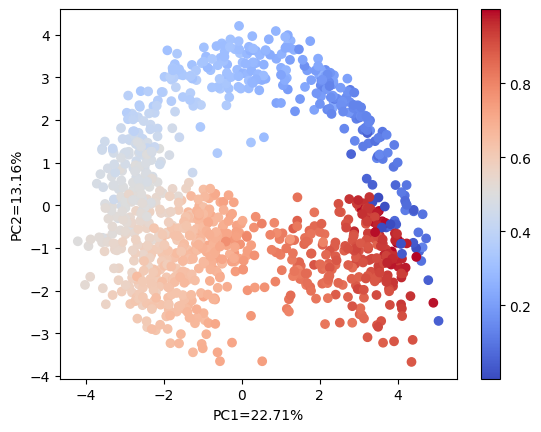

In [16]:
plt.scatter(np_data_pca[:, 0], np_data_pca[:, 1],c=th,cmap=cm.coolwarm)
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(f'PC1={ratio[0] * 100:.2f}%')
plt.ylabel(f'PC2={ratio[1] * 100:.2f}%')

In [17]:
## 采样数据
NN = 2000
k = 40 # 周期个数
data = np.zeros([np_data.shape[1], 20, NN])
for j in range(20):
    # 每个bin采样
    sample_indices = []
    for _ in range(k):
        for i in range(n_bins):
            bin_indices = np.where(adata.obs['bins'] == i)[0]
            if len(bin_indices) > 0:
                random_index = np.random.choice(bin_indices)
                sample_indices.append(random_index)
    data[:, j, :] = np_data[sample_indices,:].T

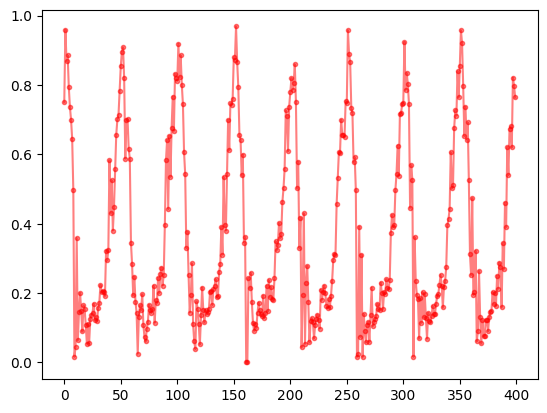

In [18]:
gene = 'CCNB1'
n = genes.index(gene)
fig, ax = plt.subplots()
ax.plot(range(400),data[n, 0, :400],'.-',alpha=0.5,color='red')

In [19]:
youtcome=np.zeros([39020, np_data.shape[1], 50, 1], dtype=np.float32)
for i in range(39020):
    j = i//1951
    k = i % 1951
    youtcome[i, :, :, :] = data[:, j, k:k+50].reshape(np_data.shape[1], 50, 1)

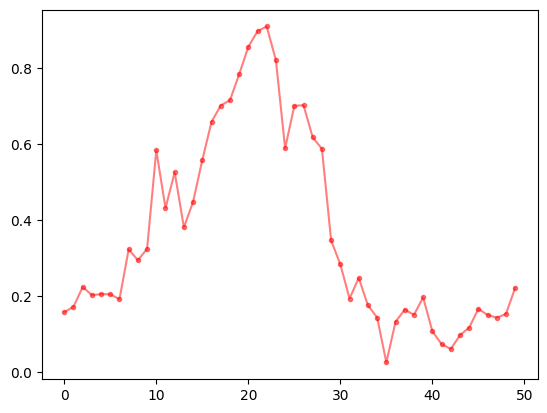

In [20]:
gene = 'CCNB1'
n = genes.index(gene)
fig, ax = plt.subplots()
ax.plot(range(50),youtcome[30, n, :, :],'.-',alpha=0.5,color='red')
# plt.savefig('1.png')

In [21]:
index = [o for o in range(youtcome.shape[0])]
np.random.shuffle(index)
ynew = youtcome[index, :, :, :]
train_data = ynew[: youtcome.shape[0] // 10 * 8, :, :, :]
val_data = ynew[youtcome.shape[0] // 10 * 8:youtcome.shape[0] // 10 * 9, :, :, :]
test_data = ynew[youtcome.shape[0] // 10 * 9:, :, :, :]

train_data = torch.tensor(train_data)
val_data = torch.tensor(val_data)
test_data = torch.tensor(test_data)

print('\n Train data size:', train_data.shape)
print('\n Val data size:' , val_data.shape)
print('\n Test data size:' , test_data.shape)
print('\n----------   Finsh generating time series data ----------')


 Train data size: torch.Size([31216, 1066, 50, 1])

 Val data size: torch.Size([3902, 1066, 50, 1])

 Test data size: torch.Size([3902, 1066, 50, 1])

----------   Finsh generating time series data ----------


In [22]:
results = [train_data, val_data, test_data]

In [23]:
with open('data.pickle', 'wb') as f:
    pickle.dump(results, f)